<h1 align="center">SWDB Problem Set: Becoming a Data Detective</h1>
<h3 align="center">From someone else's figure to your own analysis</h3>
<p align="center"><b>SOLUTIONS</b> &mdash; worked on the V1 Deep Dive dataset</p>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>How this problem set works</h2>

This morning you explored a dataset and made figures. Those figures are now posted on Slack.

**Your starting point is one of your classmates' figures.** Pick any figure from the channel, along
with the dataset it came from &mdash; ideally one you did *not* work on this morning.

| Part | Task |
| --- | --- |
| 1 | Load their dataset and find the pieces the figure needs |
| 2 | Reproduce the figure, and interrogate what it shows |
| 3 | Align activity to event onsets: raster and PSTH |
| 4 | Signal and noise correlations, and whether to trust them |

You already have the data-access skills for Part 1 from this morning's tutorial. This problem set is
about what comes after loading: **shaping data, and checking whether the result means anything.**

**Deliverable:** a short README naming the figure and dataset you chose, the decisions you made at
each step, and an honest assessment of what your numbers do and do not support.

<b>Every dataset is different, and the notebook does not know which one you picked.</b> The code
cells are prompts, not templates &mdash; you write what goes in them, using the access patterns from
this morning. Only a few things are given: the imports, and two helper functions from the tutorial.

The differences you will run into are not cosmetic. Across the datasets in this workshop:

- **Recording modality** &mdash; a continuous calcium signal in some, discrete spike times in
  others. Spikes need binning before anything here applies.
- **Sampling rate** &mdash; from a few Hz to tens of kHz, which sets what timing you can resolve.
- **Number of neurons** &mdash; tens to thousands, which changes what is tractable in one pass.
- **Stimulus structure** &mdash; many conditions with few repeats, few conditions with many, or no
  sensory stimulus at all.
- **What was recorded alongside** &mdash; running, licking, pupil, reward; some datasets have all of
  it, some none.
- **Where things live in the file** &mdash; container and column names differ, and so does which
  container holds the trial table.

None of that is written on the outside of the file. **You have to look.** Part of each prompt is
deciding whether the analysis it asks for even applies to your dataset &mdash; and saying so when it
does not.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>Taking it slow: Analysis step by step</h2>

You can now generate an analysis faster than you can check one. Ask an LLM for a correlation matrix
and you will have one in thirty seconds, beautifully formatted, with a colorbar.

The problem is that a result computed on four trials can look exactly like a result computed on four
hundred. A bug can look exactly like a finding. A correlation computed in a window where nothing
happened can look exactly like a real effect.

So the questions to keep asking are:

- **What is actually in this file?** Not what you assume &mdash; what is there.
- **Does this dataset support the question I am asking?**
- **How is the data being transformed?** Plot the data after each step.
- **What would make this result wrong?** Name it before you see the answer.

</div>

---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 1: Load the dataset and find the pieces you need</h1>

Same access pattern as this morning: metadata CSV, then navigate to a session's NWB file, then dot
and bracket notation into the containers.

**Your classmate's figure tells you what to look for.** Before you open anything, list the pieces the
figure needs &mdash; neural activity, plus whatever else it plots: a behavioral trace, epoch
boundaries, trial times, stimulus identity.

Then find each one, and note the ones that turn out not to exist. **A piece being absent is a
finding about the dataset, not a failure.** Some datasets have no running wheel, no pupil camera, no
visual stimulus at all. You will build the figure from what is there.

</div>

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pynwb
from scipy import stats

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)

data_dir = '/data'

In [2]:
metadata = pd.DataFrame({'subject_id': [427836], 'session_date': ['2019-02-19'],
                         'genotype': ['Slc17a7-IRES2-Cre;Camk2a-tTA;Ai94'],
                         'column': [1], 'volume': [1]})
metadata.head()

,subject_id,session_date,genotype,column,volume
0,427836,2019-02-19,Slc17a7-IRES2-Cre;Camk2a-tTA;Ai94,1,1


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Find a session to work with. Which subject and session type does your
classmate's figure come from?

</div>

In [3]:
nwb_path = 'data/v1dd.nwb.zarr'
nwb_path

'data/v1dd.nwb.zarr'

In [4]:
nwb = pynwb.read_nwb(nwb_path)
print(type(nwb).__name__)

NWBFile


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Find the data the figure needs</h3>

Four containers hold almost everything. Which one holds what **varies by dataset**, so list all four
before you index into any of them.

| container | commonly holds |
| --- | --- |
| `processing` | processed neural activity, and often behavior |
| `intervals` | epoch tables, trial tables, stimulus presentation tables |
| `stimulus` | stimulus templates &mdash; but in some datasets, the trial tables too |
| `acquisition` | raw acquired signals |

The last row is not hypothetical: some datasets put their trial tables in `stimulus` and leave
`intervals` holding only epochs. If you look in one container, find nothing, and conclude the data
is missing, you will be wrong. **Print all four.**

</div>

In [5]:
print('processing :', list(nwb.processing.keys()))
print('intervals  :', list(nwb.intervals.keys()) if nwb.intervals else [])
print('acquisition:', list(nwb.acquisition.keys()))
print('stimulus   :', list(nwb.stimulus.keys()) if nwb.stimulus else [])
if getattr(nwb, 'units', None) is not None:
    print('units      : yes,', len(nwb.units), 'rows')

processing : ['behavior', 'plane-0', 'plane-1', 'plane-2', 'plane-3', 'plane-4', 'plane-5']
intervals  : ['epochs', 'stimulus_table']
acquisition: ['vasculature_maps']
stimulus   : ['locally_sparse_noise', 'natural_images', 'natural_movie']


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Is your dataset continuous or spiking?</b> This is the first fork in the road, and it
changes what "activity" even means.

<b>Continuous</b> (calcium imaging, LFP): a `(n_timepoints, n_cells)` array already exists in the
file. Find it and you are done.

<b>Spiking</b> (Neuropixels, sorted electrophysiology): there is no such array. Each unit carries its
own list of spike times, usually in a `units` table, and you must <b>bin</b> them yourself &mdash;
choose a bin width, count spikes per bin, divide by the width to get a rate in spikes/s. Everything
downstream then works the same way.

Two decisions come with spiking data, and neither has a default:

- <b>Which units.</b> Spike sorting produces more units than you should analyze. There will be
  quality-control columns (`is_qc_pass`, `firing_rate`, `presence_ratio`, `snr`) and often an
  anatomical label. Select on them explicitly and say what you selected &mdash; a session can drop
  from thousands of units to dozens, and the ones you drop change your answer.
- <b>Bin width.</b> Too wide blurs the response; too narrow leaves mostly-empty bins and noisy
  single-trial estimates. Try a few and see how much your answer moves.

<pre>
bin_width = 0.010                                    # seconds -- your decision
edges = np.arange(0, t_end + bin_width, bin_width)
counts, _ = np.histogram(one_unit_spike_times, bins=edges)
rate = counts / bin_width                            # spikes/s
bin_centres = edges[:-1] + bin_width / 2
</pre>

Sparse binned spikes behave like a deconvolved calcium trace: sharper in time, and noisy per
trial.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Two things to check as you pull out the activity trace.</b>

<b>Timestamps.</b> Some datasets store an explicit `timestamps` array; others store a sampling
`rate` and a `starting_time`, and you reconstruct the times yourself. Everything downstream needs
real times in seconds, so check which you have &mdash; `series.timestamps` is `None` when the file
uses a rate.

<b>Lazy loading.</b> NWB data objects do not load until you index them. That is what lets you open a
50&nbsp;GB file instantly, but it means `data.std()` may fail where `np.std(data)` works. Convert
with `np.asarray()` once you know the array is small enough to hold, or slice first.

</div>

In [6]:
plane = 'plane-0'
dff_series = nwb.processing[plane]['dff']

dff = dff_series.data[:]
ts = dff_series.timestamps[:]

print('dff shape (nframes, nrois):', np.shape(dff))
print('timestamps shape:', np.shape(ts))
print(f'frame rate: {1 / np.median(np.diff(ts)):.2f} Hz')
print(f'session duration: {ts[-1] / 60:.1f} min')

dff shape (nframes, nrois): (21707, 35)
timestamps shape: (21707,)
frame rate: 6.09 Hz
session duration: 59.5 min


In [7]:
stimulus_table = nwb.intervals['stimulus_table'].to_dataframe()

running = nwb.processing['behavior']['running_speed']
running_speed = running.data[:]
running_ts = running.timestamps[:]

print('stimulus_table:', stimulus_table.shape)
print('running_speed: ', running_speed.shape)

stimulus_table: (12530, 12)
running_speed:  (179640,)


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Plotting a long recording.</b> A whole session at a fine sampling rate can be hundreds of
thousands of points &mdash; slow to draw and impossible to read. Plot a slice instead, but choose the
slice from the data rather than picking a round number: an arbitrary window can easily contain no
activity at all, and an empty panel looks identical to a broken one.

</div>

plotting ROI 0 (SNR 5.27, median 2.77)


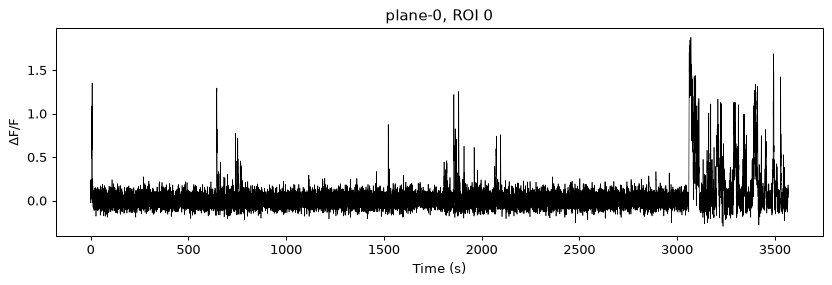

In [8]:
dff = np.asarray(dff)
usable = np.flatnonzero(~np.isnan(dff).all(axis=0))
snr = np.percentile(dff[:, usable], 99, axis=0) / np.std(dff[:, usable], axis=0)
example_roi = int(usable[np.argmax(snr)])
print(f'plotting ROI {example_roi} (SNR {snr.max():.2f}, median {np.median(snr):.2f})')
plt.figure(figsize=(11, 3))
plt.plot(ts, dff[:, example_roi], 'k', lw=0.5)
plt.xlabel('Time (s)'); plt.ylabel(r'$\Delta$F/F')
plt.title(f'{plane}, ROI {example_roi}')
plt.show()

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Look at that trace for a few seconds before moving on. Is anything about it
surprising? Would you have noticed if you had skipped straight to the analysis?

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>The variables the rest of the notebook uses</h3>

**This is the only cell you edit to run this notebook on a different dataset.** Point these names at
the equivalent pieces of your NWB file; nothing after this cell refers to a dataset by name.

</div>

In [9]:
activity = dff
timestamps = ts
events = stimulus_table

CONDITION_COLUMN = 'stimulus_condition_id'
ONSET_COLUMN = 'start_time'
activity_events = np.asarray(nwb.processing[plane]['events'].data[:])

print('activity:', activity.shape, '| events:', events.shape)
print('conditions:', events[CONDITION_COLUMN].nunique())

activity: (21707, 35) | events: (12530, 12)
conditions: 2674


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Print the columns of your stimulus table. Which describe *what was
presented*, which describe *what the animal did*, and which are bookkeeping?

Note any column whose meaning you cannot guess &mdash; that is a databook lookup for your README.

</div>

In [10]:
print(list(events.columns))
events.head()

['stim_name', 'start_time', 'stop_time', 'temporal_frequency', 'spatial_frequency', 'center_azimuth', 'center_elevation', 'direction', 'frame', 'image_order', 'image_index', 'stimulus_condition_id']


,stim_name,start_time,stop_time,temporal_frequency,spatial_frequency,center_azimuth,center_elevation,direction,frame,image_order,image_index,stimulus_condition_id
id,,,,,,,,,,,,
0,drifting_gratings_full,59.921925,61.906906,1.0,0.04,0.0,0.0,270.0,NaN,NaN,NaN,9
1,drifting_gratings_full,62.924423,64.909477,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,24
2,drifting_gratings_full,65.926987,67.911926,1.0,0.08,0.0,0.0,90.0,NaN,NaN,NaN,15
3,drifting_gratings_full,68.929405,70.914467,1.0,0.04,0.0,0.0,120.0,NaN,NaN,NaN,4
4,drifting_gratings_full,71.931923,73.916893,1.0,0.08,0.0,0.0,150.0,NaN,NaN,NaN,17


---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 2: Reproduce the figure, and interrogate what it shows</h1>

You have your classmate's figure. You do not have their code, and you may not have a caption either.

<b>Before you write anything, write down what you think the figure shows.</b> One or two sentences,
in your notebook, as a claim someone could disagree with: <i>"activity is higher during X than during
Y"</i>, <i>"the response is larger on this trial type"</i>, <i>"these two signals rise together."</i>

Two reasons this comes first. It commits you to an interpretation before the data can talk you into
one &mdash; and it converts a picture into something you can actually test. A figure cannot be right
or wrong. A claim can.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Write your claim about the figure you picked, in the cell below, before you
write any code.

Be specific enough to be wrong. "There is neural activity" is not a claim; "population activity is
higher in the second half of the session" is.

</div>

_Your claim:_

<!-- write it here -->


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Is your timeseries actually continuous?</b>

Most of the time it is. Many datasets record straight through, and this check takes one line and
returns nothing interesting. Do it anyway, because when it <i>does</i> find something the default
plot will not tell you.

Some acquisition systems write behavioral streams per block rather than continuously, so an
experimenter break, a rig adjustment or a script restart can leave an interval with no samples at
all &mdash; the timestamps just jump. Whether that happened is a property of how your session was
run, not something you can infer from the plot.

And the plot will not warn you: <code>plot()</code> draws a straight line between consecutive samples
regardless of how far apart in time they are, so a ten-minute hole becomes a flat segment that looks
exactly like an animal sitting still. <b>Missing data and zero are not the same thing, and the
default plot renders them identically.</b>

So: check the interval between samples once, before you trust any flat stretch. If there are no
gaps &mdash; the common case &mdash; you have spent one cell and can plot normally. If there are, use
the helper below to break the line at them instead of interpolating across.

</div>

In [11]:
def break_gaps(t, y, factor=10):
    dt = np.diff(t)
    typical = np.median(dt)
    breaks = np.flatnonzero(dt > factor * typical)
    if len(breaks) == 0:
        return t, y
    return (np.insert(np.asarray(t, float), breaks + 1, np.nan),
            np.insert(np.asarray(y, float), breaks + 1, np.nan))

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** For each timeseries in your figure, report the typical sampling interval and
whether any interval is much larger than it.

**Finding none is the likely outcome and a perfectly good answer** &mdash; write down that you
checked and the trace is continuous. If you do find gaps, note how much of the session they cover and
which streams are affected; they may not be the same for every signal.

</div>

In [12]:
for name, t in [('activity', timestamps)] + (
        [('running', running_ts)] if 'running_ts' in dir() else []):
    dt = np.diff(t)
    typical = np.median(dt)
    gaps = dt[dt > 10 * typical]
    print(f'{name}: typical interval {typical*1000:.1f} ms | '
          f'{len(gaps)} gaps | {gaps.sum():.0f} s with no data '
          f'({100*gaps.sum()/t[-1]:.1f}% of session)')
    if len(gaps):
        print('   gap durations (s):', np.round(np.sort(gaps)[::-1][:5], 1))

activity: typical interval 164.3 ms | 0 gaps | 0 s with no data (0.0% of session)
running: typical interval 16.7 ms | 0 gaps | 0 s with no data (0.0% of session)


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Now rebuild it</h3>

Get the pieces the figure needs and plot them. You will not match it exactly &mdash; different
smoothing, different colors, a different subset of cells &mdash; and that is fine. What matters is
that the structure you see is the same structure they saw.

If you cannot rebuild some element because the dataset does not contain it, note that and rebuild
what you can.

</div>

In [13]:
population = activity.mean(axis=1)

print('activity:  ', activity.shape, '(timepoints, cells)')
print('population:', population.shape, '(timepoints,)')

activity:   (21707, 35) (timepoints, cells)
population: (21707,) (timepoints,)


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

To shade the epochs we need their start and stop times. Where epochs live varies by dataset:
sometimes an `epoch_name` column on the stimulus table, sometimes a separate epochs table.

**Check that the column you group by actually varies.** If it takes one value, you will get a single
block spanning the session &mdash; a figure that looks fine and is wrong.

</div>

In [14]:
for column in ['epoch_name', 'stim_name', 'stimulus_block_name', 'stimulus_name']:
    if column in events.columns:
        print(f'{column}: {events[column].nunique()} distinct value(s)')
        print(events[column].value_counts().to_string())
        print()

stim_name: 7 distinct value(s)
stim_name
natural_movie                 9000
locally_sparse_noise          1705
natural_images                 944
natural_images_12              480
drifting_gratings_full         200
drifting_gratings_windowed     200
spontaneous                      1



In [15]:
epochs = nwb.intervals['epochs'].to_dataframe()

epochs = (epochs.groupby('stim_name')
          .agg(start_time=('start_time', 'min'), stop_time=('stop_time', 'max'))
          .sort_values('start_time'))
epochs['duration_s'] = (epochs.stop_time - epochs.start_time).round(1)
epochs

,start_time,stop_time,duration_s
stim_name,,,
drifting_gratings_full,59.921925,3051.394287,2991.5
drifting_gratings_windowed,350.163483,2731.127686,2381.0
locally_sparse_noise,640.404907,2103.522217,1463.1
spontaneous,881.605591,1181.838745,300.2
natural_images_12,1184.857788,1336.967773,152.1
natural_movie,1348.994507,1649.227661,300.2
natural_images,2105.624023,2404.789551,299.2


In [16]:
# Shade each epoch a different color -- same helper as the tutorial
colors = dict(zip(epochs.index, plt.cm.Pastel1.colors))


def shade_epochs(ax):
    """Shade each epoch on ax, one color per epoch label."""
    for label, row in epochs.iterrows():
        ax.axvspan(row.start_time, row.stop_time, color=colors[label], alpha=0.5, zorder=0,
                   label=label)

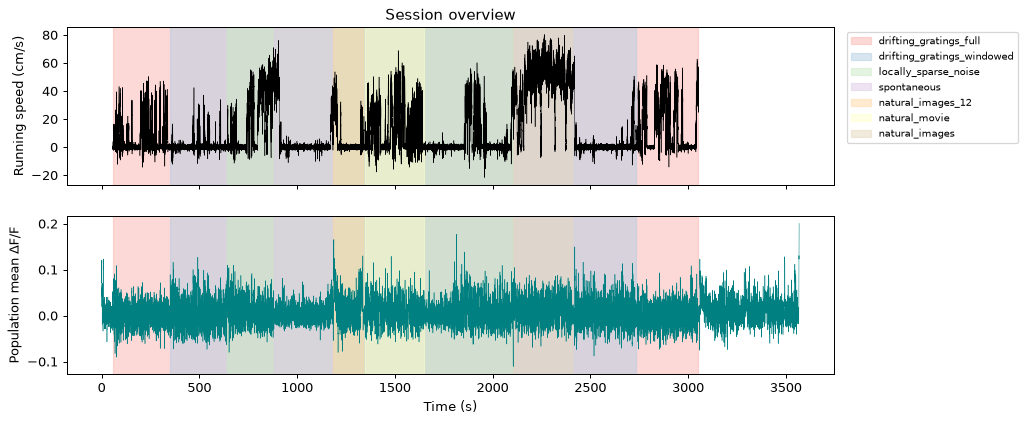

In [17]:
panels = [(timestamps, population, "Population mean " + r"$\Delta$F/F", 'teal')]
if 'running_speed' in dir():
    panels.insert(0, (running_ts, running_speed, "Running speed (cm/s)", 'k'))
fig, axes = plt.subplots(len(panels), 1, figsize=(11, 2.5*len(panels)), sharex=True, squeeze=False)
axes = axes[:, 0]
for ax, (x, y, ylabel, color) in zip(axes, panels):
    x_plot, y_plot = break_gaps(x, y)
    ax.plot(x_plot, y_plot, color=color, lw=0.4); ax.set_ylabel(ylabel); shade_epochs(ax)
axes[0].set_title('Session overview'); axes[-1].set_xlabel('Time (s)')
h, l = axes[0].get_legend_handles_labels()
u = dict(zip(l, h))
axes[0].legend(u.values(), u.keys(), bbox_to_anchor=(1.01, 1.0), loc='upper left', fontsize=8)
plt.show()

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Now test the claim you wrote above &mdash; do not eyeball it.

Turn your sentence into a number you can check. If it compares epochs, compute the mean in each one,
alongside how long each epoch lasted, when in the session it happened, and what the animal was doing.
If it compares something else, compute the equivalent.

Before you look: **what would make this comparison unfair?** Write your answer down first, then see
whether the table bears it out.

Then go back and mark your claim as supported, contradicted, or untestable with this data. All three
are legitimate outcomes and all three belong in your README.

</div>

In [18]:
rows = []
for label, row in epochs.iterrows():
    in_epoch = (timestamps >= row.start_time) & (timestamps < row.stop_time)
    in_run = (running_ts >= row.start_time) & (running_ts < row.stop_time)
    if in_epoch.sum() < 10:
        continue
    rows.append({'epoch': label,
                 'duration_s': round(float(row.stop_time - row.start_time), 1),
                 'n_samples': int(in_epoch.sum()),
                 'mid_session_min': round(float(row.start_time + row.stop_time) / 120, 1),
                 'mean_running': round(float(running_speed[in_run].mean()), 2),
                 'mean_activity': round(float(population[in_epoch].mean()), 4)})

pd.DataFrame(rows)

,epoch,duration_s,n_samples,mid_session_min,mean_running,mean_activity
0,drifting_gratings_full,2991.5,18199,25.9,11.73,0.0091
1,drifting_gratings_windowed,2381.0,14485,25.7,12.03,0.0104
2,locally_sparse_noise,1463.1,8902,22.9,9.24,0.0096
3,spontaneous,300.2,1828,17.2,5.35,0.0051
4,natural_images_12,152.1,925,21.0,5.83,0.0211
5,natural_movie,300.2,1826,25.0,14.35,0.0114
6,natural_images,299.2,1820,37.6,44.65,0.0125


---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 3: Align activity to event onsets</h1>

The session overview shows everything at once, which means it shows very little. To see a response
you need to **align** activity to the times when something happened, and look across repeats.

"Something happened" need not be a visual stimulus. It might be a sound, an optogenetic pulse, a
reward, a lick, or the start of a trial. Anything with a repeatable onset time works the same way
&mdash; and the rest of this notebook says "event" rather than "stimulus" for that reason.

This morning's tutorial averaged across presentations. Here we look at what the average hides.

</div>

In [19]:
events[CONDITION_COLUMN].value_counts()

stimulus_condition_id
1768    40
1762    40
1766    40
1769    40
1765    40
        ..
1638     1
1639     1
1640     1
1641     1
1642     1
Name: count, Length: 2674, dtype: int64

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Are all of these events the same kind of event?</h3>

An event table usually contains rows that are **not equivalent trials**. Depending on the dataset
that might be first versus repeated presentations, rewarded versus unrewarded trials, different
stimulus families, trials the animal responded to versus ignored, blocks recorded before and after
a manipulation, or blank and omitted entries that are not events at all.

This matters before you align anything, for two reasons:

- **Response magnitude can differ several-fold between trial types.** Averaging them together dilutes
  the response toward whichever type is most numerous &mdash; which is often the weakest one.
- **Trial types differ in what else is happening.** Reward, licking, and arousal ride along with some
  trial types and not others, so a difference you attribute to the stimulus may not be about the
  stimulus.

Find the columns in your table that distinguish trial types, and count them.

</div>

In [20]:
for column in ['stim_name', 'stimulus_name', 'is_change', 'omitted']:
    if column in events.columns:
        print(f'{column}:')
        print(events[column].value_counts().to_string())
        print()

stim_name:
stim_name
natural_movie                 9000
locally_sparse_noise          1705
natural_images                 944
natural_images_12              480
drifting_gratings_full         200
drifting_gratings_windowed     200
spontaneous                      1



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

To compare them we need to cut a window of data around each onset. Same
`align_to_events` helper as this morning's tutorial.

</div>

In [21]:
def align_to_events(data, timestamps, event_times, pre=0.5, post=1.5):
    """Cut a window of data around each event time.

    Returns (windows, t) where t is time in seconds relative to the event.
    """
    dt = np.median(np.diff(timestamps))
    n_pre, n_post = int(pre / dt), int(post / dt)

    windows = []
    for event_time in event_times:
        i = np.searchsorted(timestamps, event_time)

        # skip events too close to the start or end of the recording
        if i - n_pre >= 0 and i + n_post <= len(timestamps):
            windows.append(data[i - n_pre:i + n_post])

    t = np.arange(-n_pre, n_post) * dt
    return np.array(windows), t

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Pick two trial types from your table and align the population average to
each separately, then plot both on the same axes.

Write down your prediction first: do you expect a difference, and how large?

Then choose which type to carry forward, and one condition within it. Name three things, because the
rest of Part 3 refers to them:

| name | what it holds |
| --- | --- |
| `onsets_pool` | onset times of ALL trials of your chosen type |
| `onsets` | onset times of the one condition you picked |
| `ROI` | index of your example cell |

</div>

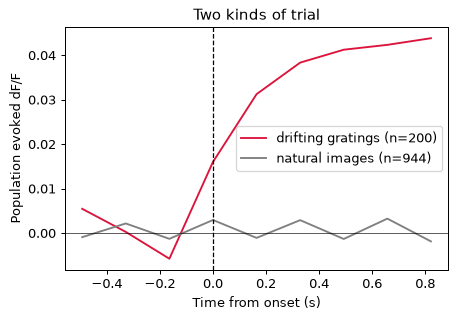

In [22]:
population = activity.mean(axis=1)

# V1DD: compare two stimulus families
group_a = events.loc[events.stim_name == 'drifting_gratings_full', ONSET_COLUMN].values
group_b = events.loc[events.stim_name == 'natural_images', ONSET_COLUMN].values

plt.figure(figsize=(5.5, 3.5))
for onsets_type, label, color in [(group_a, 'drifting gratings', 'crimson'),
                                  (group_b, 'natural images', 'gray')]:
    windows_type, t_type = align_to_events(population, timestamps, onsets_type,
                                           pre=0.5, post=1.0)
    baseline = windows_type[:, t_type < 0].mean(axis=1, keepdims=True)
    evoked = (windows_type - baseline).mean(axis=0)
    plt.plot(t_type, evoked, color=color, label=f'{label} (n={len(windows_type)})')

plt.axvline(0, color='k', ls='--', lw=1)
plt.axhline(0, color='k', lw=0.5)
plt.xlabel('Time from onset (s)')
plt.ylabel('Population evoked dF/F')
plt.legend()
plt.title('Two kinds of trial')
plt.show()

In [23]:
onsets_pool = group_a
trial_type_mask = events.stim_name == 'drifting_gratings_full'

condition = events.loc[trial_type_mask, CONDITION_COLUMN].value_counts().index[0]
onsets = events.loc[trial_type_mask & (events[CONDITION_COLUMN] == condition),
                    ONSET_COLUMN].values

print(f'condition: {condition} | presentations of this type: {len(onsets)}')

condition: 9 | presentations of this type: 8


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Which cell to look at?</h3>

Showing "ROI 0" is an arbitrary choice you did not disclose. Ranking cells by how much they respond
is a *different* undisclosed choice unless you say so. Pick deliberately and write it down.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Which signal do you align?</b> A calcium dataset usually ships more than one
representation of the same activity: a continuous fluorescence trace, and a deconvolved estimate of
when the cell actually fired. They share timestamps, so either can be aligned the same way &mdash; but
they answer different questions and they do not give the same picture.

We use the <b>deconvolved events</b> for the aligned figures below. The continuous trace carries the
indicator's slow decay, which smears a brief response forward by hundreds of milliseconds and makes
every neighbouring cell look correlated through shared baseline drift. Events are sparse and
temporally tighter, so a raster of them is closer to what the cell did.

That sparsity has a cost we will meet in Part 4: most single trials are exactly zero, so per-trial
estimates are noisier even though the average looks cleaner. Set the choice in one place so you can
switch it and see for yourself.

</div>

In [24]:
if 'activity_events' in dir() and activity_events is not None:
    aligned_signal = activity_events
    SIGNAL_LABEL = 'events'
else:
    aligned_signal = activity
    SIGNAL_LABEL = 'activity'
print('aligning', SIGNAL_LABEL, '|', aligned_signal.shape)

aligning events | (21707, 35)


In [25]:
pre, post = 0.5, 1.0
after = np.array([activity[(timestamps >= t0) & (timestamps < t0+0.5)].mean(axis=0) for t0 in onsets_pool])
before = np.array([activity[(timestamps >= t0-0.25) & (timestamps < t0)].mean(axis=0) for t0 in onsets_pool])
difference = after - before
with np.errstate(invalid='ignore'):
    modulation = np.nanmean(difference, axis=0) / np.nanstd(difference, axis=0)
ROI = int(np.nanargmax(modulation))
print(f'most modulated cell: ROI {ROI} (score {modulation[ROI]:.3f})')
print(f'median across cells: {np.nanmedian(modulation):.3f}')

most modulated cell: ROI 14 (score 0.860)
median across cells: 0.412


In [26]:
windows, t = align_to_events(activity[:, ROI], timestamps, onsets, pre=pre, post=post)
print('windows shape (n_presentations, n_frames):', windows.shape)

windows shape (n_presentations, n_frames): (8, 9)


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Compare the number of windows you got back against the number of onsets you
asked for. Are they the same?

If not, read the helper again and work out where the missing trials went &mdash; then decide whether
losing them matters for your analysis.

This is worth doing every time you call something that returns one row per trial. A function that
quietly returns fewer rows than you gave it will not raise an error; it will just make your
n smaller than you think it is.

</div>

In [27]:
print('onsets:           ', len(onsets))
print('windows returned: ', windows.shape[0])
print('trials dropped:   ', len(onsets) - windows.shape[0])

onsets:            8
windows returned:  8
trials dropped:    0


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Raster and PSTH</h3>

The raster shows every trial; the PSTH is their average. Plot them together so you can see what the
average discards.

</div>

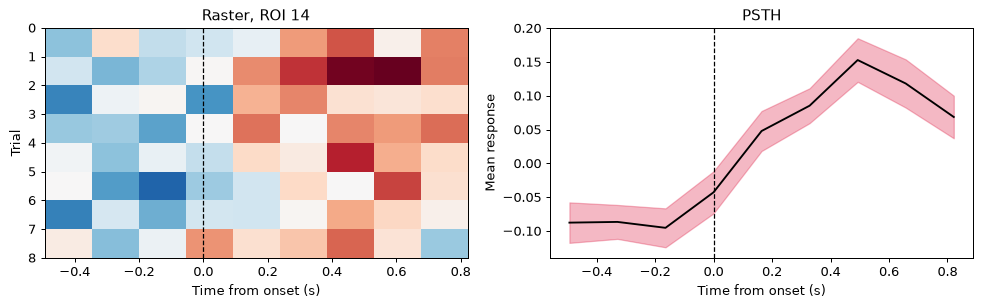

In [28]:
mean = windows.mean(axis=0)
sem = windows.std(axis=0) / np.sqrt(len(windows))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
lim = np.nanpercentile(np.abs(windows), 99)
axes[0].imshow(windows, aspect='auto', cmap='RdBu_r', vmin=-lim, vmax=lim,
               extent=[t[0], t[-1], len(windows), 0])
axes[0].set_ylabel('Trial'); axes[0].set_title(f'Raster, ROI {ROI}')
axes[1].plot(t, mean, 'k')
axes[1].fill_between(t, mean-sem, mean+sem, color='crimson', alpha=0.3)
axes[1].set_ylabel('Mean response'); axes[1].set_title('PSTH')
for ax in axes:
    ax.axvline(0, color='k', ls='--', lw=1); ax.set_xlabel('Time from onset (s)')
plt.tight_layout(); plt.show()

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Now do it for every cell and plot the result as a heatmap, sorted by
response magnitude. How many cells respond at all?

</div>

In [29]:
responses = []
for roi in range(activity.shape[1]):
    windows_roi, t = align_to_events(activity[:, roi], timestamps, onsets, pre=pre, post=post)
    responses.append(windows_roi.mean(axis=0))

responses = np.array(responses)
print('responses shape (n_cells, n_timepoints):', responses.shape)

responses shape (n_cells, n_timepoints): (35, 9)


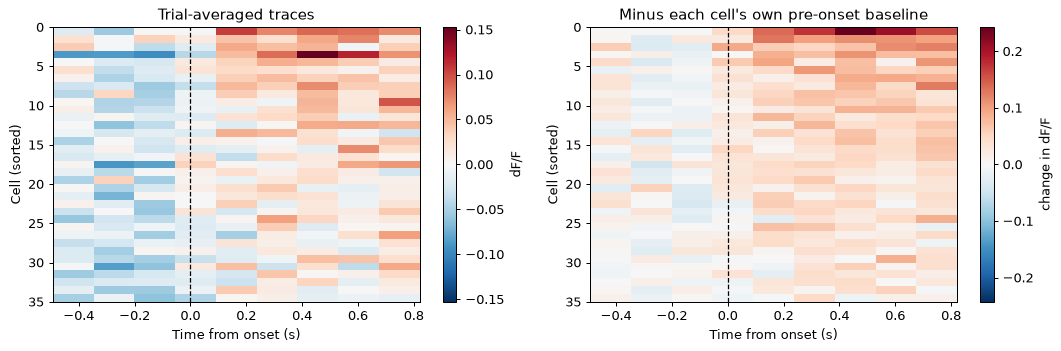

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

order_raw = np.argsort(responses.mean(axis=1))[::-1]
lim = np.abs(responses).max()
im0 = axes[0].imshow(responses[order_raw], aspect='auto', cmap='RdBu_r', vmin=-lim, vmax=lim,
                     extent=[t[0], t[-1], len(responses), 0])
axes[0].set_title('Trial-averaged traces')
plt.colorbar(im0, ax=axes[0], label='dF/F')

baseline = responses[:, t < 0].mean(axis=1, keepdims=True)
change = responses - baseline
order = np.argsort(change[:, t >= 0].mean(axis=1))[::-1]
lim = np.abs(change).max()
im1 = axes[1].imshow(change[order], aspect='auto', cmap='RdBu_r', vmin=-lim, vmax=lim,
                     extent=[t[0], t[-1], len(change), 0])
axes[1].set_title("Minus each cell's own pre-onset baseline")
plt.colorbar(im1, ax=axes[1], label='change in dF/F')

for ax in axes:
    ax.axvline(0, color='k', ls='--', lw=1)
    ax.set_xlabel('Time from onset (s)')
    ax.set_ylabel('Cell (sorted)')

plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>The same analysis on a different signal</h3>

Many datasets give you more than one version of "neural activity". Calcium imaging pipelines often
provide both a **continuous** signal (dF/F) and a **sparse, deconvolved** one (often called events
or spikes) &mdash; an estimate of when activity actually occurred, with the slow decay of the
indicator removed. Some provide only one.

**Check what your dataset has before assuming.** List the interfaces in the processing container. If
there is only one representation, say so in your README and skip this comparison &mdash; that is a
property of the dataset worth recording, not a step you failed.

Where both exist they are not interchangeable, and which you use changes your numbers.

</div>

In [31]:
if activity_events is not None:
    activity_events = np.where(np.abs(activity_events) < 1e-12, 0.0, activity_events)
    print('primary:', activity.shape, '| fraction exactly zero: %.3f' % (activity == 0).mean())
    print('second: ', activity_events.shape,
          '| fraction exactly zero: %.3f' % (activity_events == 0).mean())
    print('timestamps shared:', activity_events.shape[0] == len(timestamps))
else:
    print('this dataset has only one activity representation')

primary: (21707, 35) | fraction exactly zero: 0.047
second:  (21707, 35) | fraction exactly zero: 0.969
timestamps shared: True


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** If your dataset has two activity representations, align both to the same
onsets and plot the trial-averaged population response side by side. What differs &mdash; the
duration, the shape, the size relative to baseline?

If it has only one, note that in your README and move on.

</div>

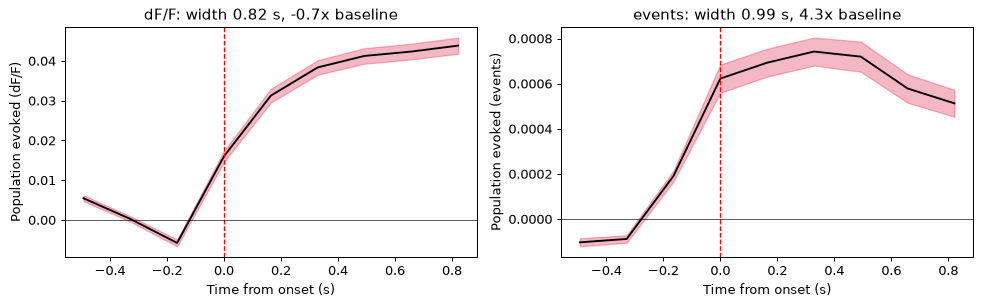

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

for ax, A, label in [(axes[0], activity, 'dF/F'),
                     (axes[1], activity_events, 'events')]:
    windows_pop, t_pop = align_to_events(A.mean(axis=1), timestamps, onsets_pool,
                                         pre=0.5, post=1.0)
    baseline = windows_pop[:, t_pop < 0].mean(axis=1, keepdims=True)
    evoked = (windows_pop - baseline)
    mean = evoked.mean(axis=0)
    sem = evoked.std(axis=0) / np.sqrt(len(evoked))

    above_half = mean > mean.max() / 2
    width = above_half.sum() * np.median(np.diff(t_pop))
    raw = windows_pop.mean(axis=0)
    contrast = raw.max() / raw[t_pop < 0].mean()

    ax.plot(t_pop, mean, 'k')
    ax.fill_between(t_pop, mean - sem, mean + sem, color='crimson', alpha=0.3)
    ax.axvline(0, color='red', ls='--', lw=1)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlabel('Time from onset (s)')
    ax.set_ylabel(f'Population evoked ({label})')
    ax.set_title(f'{label}: width {width:.2f} s, {contrast:.1f}x baseline')

plt.tight_layout()
plt.show()

---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 4: Signal and noise correlations</h1>

<h3>First, the math</h3>

The Pearson correlation between two variables $x$ and $y$ is

$$ r = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}
              {\sqrt{\sum_i (x_i - \bar{x})^2}\;\sqrt{\sum_i (y_i - \bar{y})^2}} $$

In words:

1. **Center** each variable by subtracting its mean.
2. **Multiply** the centered values pointwise and sum &mdash; large and positive when they vary
   together, negative when oppositely, near zero when unrelated.
3. **Normalize** by each variable's spread, forcing the result between -1 and +1.

Compute it once by hand before running it thousands of times.

</div>

In [33]:
x = activity[:, 0]
y = activity[:, 1]

x_centered = x - x.mean()
y_centered = y - y.mean()
numerator = np.sum(x_centered * y_centered)
denominator = np.sqrt(np.sum(x_centered ** 2)) * np.sqrt(np.sum(y_centered ** 2))

print('n observations:  ', len(x))
print('r by hand:       ', round(numerator / denominator, 6))
print('r from np.corrcoef:', round(np.corrcoef(x, y)[0, 1], 6))

n observations:   21707
r by hand:        0.04346
r from np.corrcoef: 0.04346


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Two consequences that matter for everything below:

- $r$ says nothing about response **size**, only whether two things move together.
- $r$ is computed over a set of paired observations, and **how many observations you have determines
  how noisy $r$ is** &mdash; but the value itself gives you no clue how many there were.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** What does a given value of $r$ look like? Simulate pairs with known
correlations and plot them.

</div>

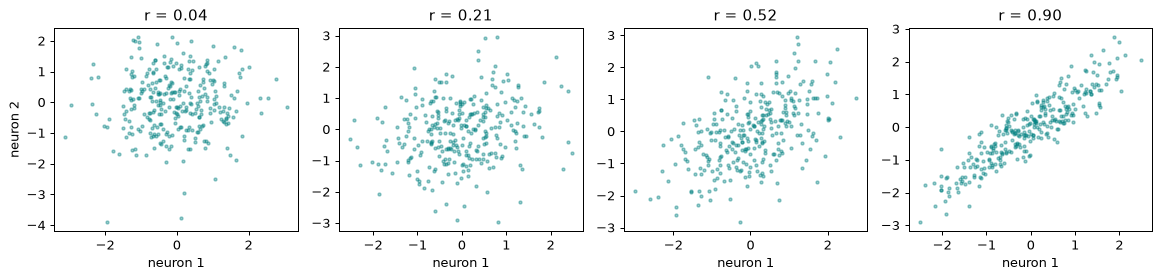

In [34]:
rng = np.random.default_rng(0)
n = 300
fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
for ax, target_r in zip(axes, [0.0, 0.2, 0.5, 0.9]):
    a = rng.normal(size=n)
    b = target_r * a + np.sqrt(1 - target_r ** 2) * rng.normal(size=n)
    ax.scatter(a, b, s=6, alpha=0.4, color='teal')
    ax.set_title(f'r = {np.corrcoef(a, b)[0, 1]:.2f}')
    ax.set_xlabel('neuron 1')
axes[0].set_ylabel('neuron 2')
plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Two reasons neurons are correlated</h3>

- **Signal correlation.** Do they respond similarly *across conditions*? Correlate the two neurons'
  tuning curves &mdash; their average response to each condition.
- **Noise correlation.** When the *same* condition repeats, do they fluctuate together around their
  own averages? Subtract each condition's mean and correlate the residuals.

A "condition" is whatever your event table repeats: an image, a grating direction, a tone, a
photostimulation target, a task context. All that matters is that it recurs enough times to average
over.

Same data, different thing averaged over:

| | what is correlated | one observation is |
| --- | --- | --- |
| signal | condition means | one condition |
| noise | within-condition residuals | one trial |

That last column matters more than anything else in this notebook.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 1: choose which events to use</h3>

Not every event is comparable to every other. Decide which subset is a fair comparison and write down
why.

</div>

In [35]:
# Natural images: 118 distinct images, 8 presentations each.
# We switch condition column here too -- image_index labels the images.
CONDITION_COLUMN = 'image_index'
subset = events[events.stim_name == 'natural_images'].copy()

onsets_all = subset[ONSET_COLUMN].values
labels = subset[CONDITION_COLUMN].values

print(f'{len(events)} events -> {len(subset)} after filtering')
print(pd.Series(labels).value_counts().to_string())

12530 events -> 944 after filtering
0.0      8
1.0      8
2.0      8
3.0      8
4.0      8
5.0      8
6.0      8
7.0      8
8.0      8
9.0      8
10.0     8
11.0     8
12.0     8
13.0     8
14.0     8
15.0     8
16.0     8
17.0     8
18.0     8
19.0     8
20.0     8
21.0     8
22.0     8
23.0     8
24.0     8
25.0     8
26.0     8
27.0     8
28.0     8
29.0     8
30.0     8
31.0     8
32.0     8
33.0     8
34.0     8
35.0     8
36.0     8
37.0     8
38.0     8
39.0     8
40.0     8
41.0     8
42.0     8
43.0     8
44.0     8
45.0     8
46.0     8
47.0     8
48.0     8
49.0     8
50.0     8
51.0     8
52.0     8
53.0     8
54.0     8
55.0     8
56.0     8
57.0     8
58.0     8
59.0     8
60.0     8
61.0     8
62.0     8
63.0     8
64.0     8
65.0     8
66.0     8
67.0     8
68.0     8
69.0     8
70.0     8
71.0     8
72.0     8
73.0     8
74.0     8
75.0     8
76.0     8
77.0     8
78.0     8
79.0     8
80.0     8
81.0     8
82.0     8
83.0     8
84.0     8
85.0     8
86.0     8
87.0   

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 2: one number per trial per neuron</h3>

We need a `(n_trials, n_cells)` matrix. Average each aligned window over a response window, and
subtract a **baseline** from just before onset &mdash; otherwise each trial's "response" includes
wherever the cell happened to be sitting beforehand, and those levels drift together across the
population from bleaching, arousal, and movement.

<b>Choosing the two windows is dataset-specific.</b> The response window should cover the response
your Part 3 plot showed &mdash; look at it rather than copying a number from here, since a calcium
signal and a spike rate need very different windows. The baseline window should sit in the gap
before onset, and must **exclude any stimulation artifact**: with optogenetics or electrical
stimulation the frames around the pulse can be unusable, so leave a margin on both sides.

</div>

In [36]:
RESPONSE_WINDOW = (0.0, 0.5)
BASELINE_WINDOW = (-0.5, -0.05)
rows = []
for t0 in onsets_all:
    a = (timestamps >= t0+RESPONSE_WINDOW[0]) & (timestamps < t0+RESPONSE_WINDOW[1])
    b = (timestamps >= t0+BASELINE_WINDOW[0]) & (timestamps < t0+BASELINE_WINDOW[1])
    rows.append(np.nanmean(activity[a], axis=0) - np.nanmean(activity[b], axis=0) if a.sum() and b.sum()
                else np.full(activity.shape[1], np.nan))
R = np.array(rows)
keep_rows = ~np.isnan(R).any(axis=1)
R = R[keep_rows]; labels_used = np.asarray(labels)[keep_rows]
print('R shape (n_trials, n_cells):', R.shape)
print('conditions:', len(np.unique(labels_used)))

R shape (n_trials, n_cells): (944, 35)
conditions: 118


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 3: tuning curves &mdash; look before correlating</h3>

</div>

In [37]:
conditions = np.unique(labels_used)
tuning = np.vstack([R[labels_used == c].mean(axis=0) for c in conditions])
print('tuning shape (n_conditions, n_cells):', tuning.shape)

tuning shape (n_conditions, n_cells): (118, 35)


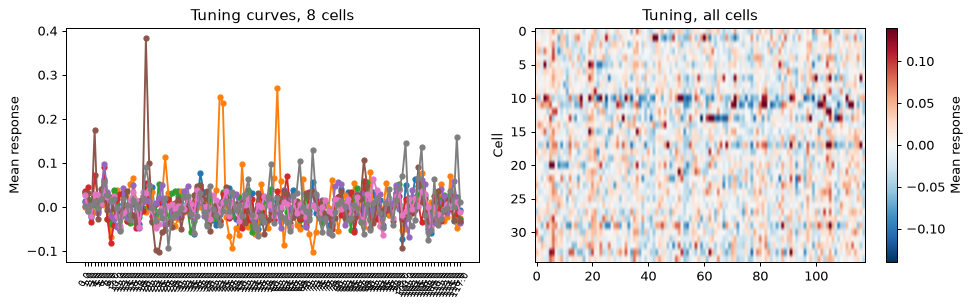

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for roi in range(min(8, tuning.shape[1])):
    axes[0].plot(range(len(conditions)), tuning[:, roi], marker='o', ms=4)
axes[0].set_xticks(range(len(conditions)))
axes[0].set_xticklabels([str(c) for c in conditions], rotation=60, fontsize=7)
axes[0].set_ylabel('Mean response'); axes[0].set_title('Tuning curves, 8 cells')
lim = np.nanpercentile(np.abs(tuning), 99)
im = axes[1].imshow(tuning.T, aspect='auto', cmap='RdBu_r', vmin=-lim, vmax=lim)
axes[1].set_ylabel('Cell'); axes[1].set_title('Tuning, all cells')
plt.colorbar(im, ax=axes[1], label='Mean response')
plt.tight_layout(); plt.show()

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** How many numbers make up one neuron's tuning curve?

That is how many paired observations each signal correlation gets. Write it down.

</div>

In [39]:
print('numbers per tuning curve:', tuning.shape[0])
print('trials available for noise correlations:', R.shape[0])

numbers per tuning curve: 118
trials available for noise correlations: 944


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 4: residuals &mdash; look before correlating</h3>

Subtract **each condition's own mean**, not the grand mean. Subtracting the grand mean would leave
the differences between conditions in the residuals, making your "noise" correlation partly a signal
correlation.

</div>

In [40]:
residuals = R.copy().astype(float)
for c in conditions:
    m = labels_used == c
    residuals[m] -= R[m].mean(axis=0)
print('residuals shape:', residuals.shape)
print('mean of residuals (should be ~0):', round(float(residuals.mean()), 12))

residuals shape: (944, 35)
mean of residuals (should be ~0): 2.9e-11


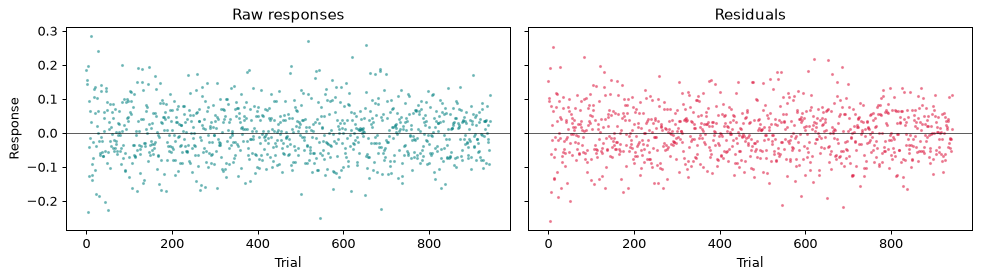

In [41]:
roi = ROI if ROI < R.shape[1] else 0
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
axes[0].plot(R[:, roi], '.', ms=3, alpha=0.4, color='teal'); axes[0].set_title('Raw responses')
axes[1].plot(residuals[:, roi], '.', ms=3, alpha=0.4, color='crimson'); axes[1].set_title('Residuals')
for ax in axes:
    ax.axhline(0, color='k', lw=0.5); ax.set_xlabel('Trial')
axes[0].set_ylabel('Response')
plt.tight_layout(); plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 5: correlate</h3>

`np.corrcoef` correlates **rows**, so transpose to get cells rather than trials. Getting this
backwards produces a plausible matrix of entirely the wrong thing &mdash; check the output shape
against the number of cells.

</div>

In [42]:
C_signal = np.corrcoef(tuning.T)
C_noise = np.corrcoef(residuals.T)
pairs = np.triu_indices(R.shape[1], k=1)
signal_values = C_signal[pairs]; noise_values = C_noise[pairs]
print(f'cells: {R.shape[1]} -> unique pairs: {len(signal_values)}')
print(f'signal correlation: mean {np.nanmean(signal_values):+.4f}   ({tuning.shape[0]} observations per pair)')
print(f'noise  correlation: mean {np.nanmean(noise_values):+.4f}   ({R.shape[0]} observations per pair)')

cells: 35 -> unique pairs: 595
signal correlation: mean +0.2494   (118 observations per pair)
noise  correlation: mean +0.0448   (944 observations per pair)


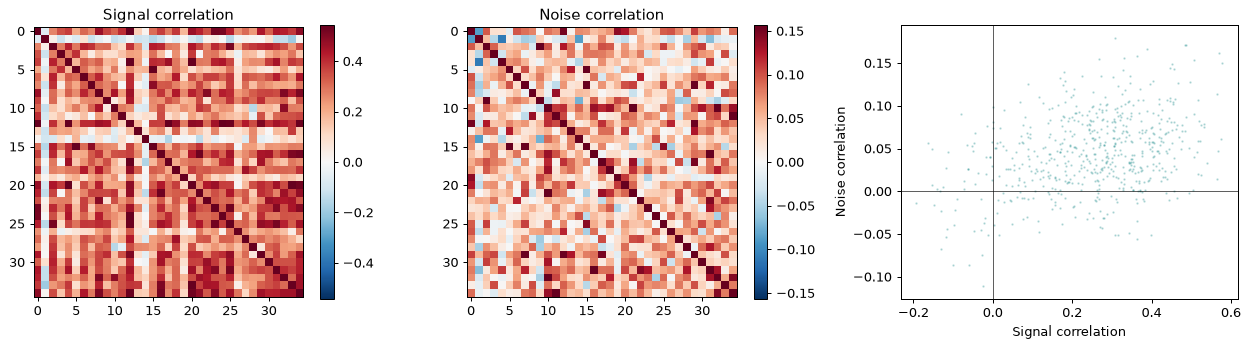

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, C, name in [(axes[0], C_signal, 'Signal'), (axes[1], C_noise, 'Noise')]:
    lim = np.nanpercentile(np.abs(C[pairs]), 99)
    im = ax.imshow(C, cmap='RdBu_r', vmin=-lim, vmax=lim)
    ax.set_title(f'{name} correlation'); plt.colorbar(im, ax=ax)
axes[2].plot(signal_values, noise_values, '.', ms=2, alpha=0.2, color='teal')
axes[2].set_xlabel('Signal correlation'); axes[2].set_ylabel('Noise correlation')
axes[2].axhline(0, color='k', lw=0.5); axes[2].axvline(0, color='k', lw=0.5)
plt.tight_layout(); plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Is this result trustworthy?</h1>

Every number so far is a point estimate with no error bar. The single most useful check: **would you
get the same answer with half the data?**

Split trials in half at random, compute the correlations on each half separately, and correlate the
two halves' answers. Split **within each condition** so both halves see every condition.

Three outcomes, and all three are informative:

- **One high, one low** &mdash; trust the high one, and say why the other is not trustworthy.
- **Both high** &mdash; you have enough data for both; proceed.
- **Both near zero** &mdash; report that. It usually means the condition variable you chose does not
  organise these neurons' responses, however well-balanced it looked in the inventory. That is a
  real result about your dataset, and it is a better README than a matrix you cannot defend.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Before running it &mdash; which do you expect to be more reliable, signal or
noise correlations? Look back at the observation counts you wrote down.

</div>

In [44]:
def correlations_from(R_sub, labels_sub):
    """Signal and noise correlation matrices from a subset of trials."""
    conds = np.unique(labels_sub)
    tuning_sub = np.vstack([R_sub[labels_sub == c].mean(axis=0) for c in conds])
    resid_sub = R_sub.astype(float).copy()
    for c in conds:
        m = labels_sub == c
        resid_sub[m] -= R_sub[m].mean(axis=0)
    return np.corrcoef(tuning_sub.T), np.corrcoef(resid_sub.T)

In [45]:
def reliability(R_sub, lab_sub, n_iter=10, seed=0):
    rng_r = np.random.default_rng(seed)
    iu = np.triu_indices(R_sub.shape[1], k=1)
    S, N = [], []
    for _ in range(n_iter):
        ha, hb = [], []
        for c in np.unique(lab_sub):
            idx = rng_r.permutation(np.flatnonzero(lab_sub == c)); h = len(idx)//2
            ha.append(idx[:h]); hb.append(idx[h:2*h])
        a, b = np.concatenate(ha), np.concatenate(hb)
        c1 = correlations_from(R_sub[a], lab_sub[a]); c2 = correlations_from(R_sub[b], lab_sub[b])
        S.append(stats.spearmanr(c1[0][iu], c2[0][iu], nan_policy='omit').statistic)
        N.append(stats.spearmanr(c1[1][iu], c2[1][iu], nan_policy='omit').statistic)
    return float(np.mean(S)), float(np.mean(N))

signal_reliability, noise_reliability = reliability(R, labels_used)
print('split-half reliability (agreement between two independent halves)')
print(f'  signal: {signal_reliability:.3f}')
print(f'  noise:  {noise_reliability:.3f}')

split-half reliability (agreement between two independent halves)
  signal: 0.566
  noise:  0.215


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Does the signal you chose change the answer?</h3>

Everything so far used one representation of activity. If your dataset provides a second one, repeat
the whole chain on it and compare the numbers that matter. If it provides only one, note that and
move on.

To repeat the chain you need the response-matrix construction as a reusable function rather than a
one-off block &mdash; so wrap it, the same way you wrapped the correlations.

</div>

In [46]:
def response_matrix(A):
    rows = []
    for t0 in onsets_all:
        a = (timestamps >= t0+RESPONSE_WINDOW[0]) & (timestamps < t0+RESPONSE_WINDOW[1])
        b = (timestamps >= t0+BASELINE_WINDOW[0]) & (timestamps < t0+BASELINE_WINDOW[1])
        rows.append(np.nanmean(A[a], axis=0) - np.nanmean(A[b], axis=0) if a.sum() and b.sum()
                    else np.full(A.shape[1], np.nan))
    M = np.array(rows)
    return M[~np.isnan(M).any(axis=1)]

In [47]:
signals = [('dff', activity)]
if activity_events is not None:
    signals.append(('events', activity_events))
rows = []
for label_s, A in signals:
    R_s = response_matrix(A)
    lab_s = labels_used[:R_s.shape[0]]
    Cs, Cn = correlations_from(R_s, lab_s)
    iu = np.triu_indices(R_s.shape[1], k=1)
    rs, rn = reliability(R_s, lab_s)
    rows.append({'signal_type': label_s,
                 'frac_zero_trials': round(float((R_s == 0).mean()), 3),
                 'signal_mean': round(float(np.nanmean(Cs[iu])), 4),
                 'noise_mean': round(float(np.nanmean(Cn[iu])), 4),
                 'signal_reliability': round(rs, 3),
                 'noise_reliability': round(rn, 3)})
pd.DataFrame(rows)

,signal_type,frac_zero_trials,signal_mean,noise_mean,signal_reliability,noise_reliability
0,dff,0.000,0.2494,0.0448,0.566,0.215
1,events,0.813,0.0677,0.0235,0.312,0.218


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>One column may not be the whole condition.</b>

A column can look like a clean condition variable &mdash; many levels, perfectly balanced &mdash;
while the stimulus varied in some <i>other</i> way at the same time. Two trials sharing that column's
value are then not repeats of the same thing, and averaging them together destroys the tuning you
were trying to measure.

Receptive-field mapping is the classic case: orientation is balanced, but the stimulus also moves
around the screen, so "144 repeats of 45&deg;" is really a handful of repeats at each of many
positions. The same trap appears whenever a design crosses two factors and you only notice one.

Check for it by asking what else varies across the trials you just called identical. Group by your
condition column, look at the other columns within a group, and see whether they are constant. If
they are not, either restrict to one level of the other factor, or make the condition the
<i>combination</i> of both.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Signal correlations need a condition that repeats. Does your dataset have
one?

Inventory the candidate columns: how many distinct values, how many repeats, how balanced.

Then answer **two separate questions**, because they can disagree:

1. **Is the analysis possible?** Does some column have enough conditions with enough repeats?
2. **Is it meaningful?** Does that column label something you would expect neurons to be tuned
   *to*, in a way that a correlation across condition means would capture?

A column can pass the first test and fail the second. State a verdict on both, and check it against
your reliability numbers.

</div>

In [48]:
rows = []
for column in events.columns:
    values = events[column].dropna()
    if len(values) == 0:
        continue
    try:
        n_conditions = values.nunique()
    except TypeError:
        continue
    if not (2 <= n_conditions <= 60):
        continue
    counts = values.value_counts()
    rows.append({'column': column, 'n_conditions': int(n_conditions),
                 'min_reps': int(counts.min()), 'max_reps': int(counts.max()),
                 'balance': round(counts.min() / counts.max(), 2)})

pd.DataFrame(rows).sort_values('n_conditions', ascending=False)

,column,n_conditions,min_reps,max_reps,balance
4,direction,12,32,32,1.0
0,stim_name,7,1,9000,0.0
1,spatial_frequency,2,192,192,1.0
2,center_azimuth,2,200,200,1.0
3,center_elevation,2,200,200,1.0


---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Summary</h1>

<h3>The process</h3>

1. **Find out what is in the file** before analyzing it &mdash; and check that the dataset supports
   your question. Sometimes the answer is no.
2. **Plot the data after each transformation.** Single trials before averages; tuning curves before
   correlations.
3. **Name every decision.** Event subset, condition column, response window, baseline. Each is a
   fork, and each belongs in your methods.
4. **Try to break your own result.** Split the data in half and see if the answer survives.
5. **Let the dataset answer back.** If the check says your result is noise, or the dataset has no
   variable that supports your question, that is the finding. Report it rather than reaching for the
   analysis you planned to run.

<h3>Traps this notebook demonstrated</h3>

| trap | how you catch it |
| --- | --- |
| A result from few observations looks like one from many | split-half reliability |
| A well-balanced condition variable that means nothing | reliability, not the inventory |
| A condition column that hides a second varying factor | group by it, check what else moves |
| Analyzing units that should have been dropped | select on quality columns, and say so |
| A helper function silently drops data | compare output shape to input |
| A column exists but carries no information | check that it actually varies |
| One bad trial turns every cell's score into NaN | count your NaNs; use `nanmean` |
| Epoch comparisons confounded with time and behavior | check durations, order, behavior |
| An example cell chosen to look good | state your selection rule |
| Data looks absent but is stored elsewhere | look in every container first |
| An index from an earlier cell after reshaping the data | re-derive indices, never carry them |

<h3>Why this matters</h3>

You can generate an analysis faster than you can validate one. The only defense is to know your data
well enough that a wrong answer looks wrong to **you** &mdash; because it will not look wrong to the
code, and it will not look wrong on the plot.

</div>